# Importing Libraries

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Downloading Financial Data

In [2]:
# Download historical price data from Yahoo Finance
stocks = ['AAPL', 'JNJ', 'JPM', 'KO', 'XOM']
start_date = '2020-01-01'
end_date = '2025-12-31'

data = yf.download(stocks, start=start_date, end=end_date)['Close']
data = data.dropna()
print(data.head())

[*********************100%***********************]  5 of 5 completed

Ticker           AAPL         JNJ         JPM         KO        XOM
Date                                                               
2020-01-02  72.333870  121.936958  118.430336  45.141266  52.947037
2020-01-03  71.630646  120.525215  116.867462  44.895000  52.521374
2020-01-06  72.201424  120.374832  116.774559  44.878574  52.924629
2020-01-07  71.861847  121.109955  114.789291  44.533802  52.491501
2020-01-08  73.017822  121.093239  115.684784  44.615891  51.699909


# Creating Log Return Data Frame

In [3]:
# Calculate log returns for each stock
# Log returns are used because they are additive over time and normally distributed
stocks_lr = np.log(data / data.shift(1))
stocks_lr = stocks_lr.dropna()

print(stocks_lr.head())

Ticker          AAPL       JNJ       JPM        KO       XOM
Date                                                        
2020-01-03 -0.009769 -0.011645 -0.013284 -0.005470 -0.008072
2020-01-06  0.007937 -0.001249 -0.000795 -0.000366  0.007649
2020-01-07 -0.004714  0.006088 -0.017147 -0.007712 -0.008218
2020-01-08  0.015958 -0.000138  0.007771  0.001842 -0.015195
2020-01-09  0.021019  0.002962  0.003644  0.018051  0.007626


# Creating Function to Calculate Portfolio Return

## Portfolio Return is given by: 
### (Asset 1 Weight x Expected Return) + (Asset 2 Weight x Expected Return)..


In [4]:
#Function to calculate portfolio return
def portfolioreturn(weights):
    return np.dot(stocks_lr.mean(),weights)*252

# Function to Calculate Portfolio Standard Deviation (Risk)
## ## Portfolio Variance Formula

$$Var[R_p] = \sum_{i=1}^{n} \omega_i^2 \sigma_i^2 + \sum_{i \neq j} \omega_i \omega_j \text{Cov}[R_i, R_j]$$

In [5]:
def portfoliostd(weights):
    return (np.dot(np.dot(stocks_lr.cov(),weights),weights))**(1/2)*np.sqrt(252)
    


# Function to Generate Random Weights

In [6]:
def weightscreator(stocks_lr):
    rand = np.random.random(len(stocks_lr.columns))
    rand /= rand.sum()
    return rand 

# Function to Find Returns and Standard Deviation for "i" Random Portfolio Weight Arrays

In [7]:
returns = []
stds = []
w = []

for i in range(100000): #Use the number of iterations you seem fit
    weights = weightscreator(stocks_lr)
    returns.append(portfolioreturn(weights))
    stds.append(portfoliostd(weights))
    w.append(weights)

# Using MatPlotLib To Plot the Efficient Frontier

## Where Efficient Frontier is the graph between Portfolio Risk and Return

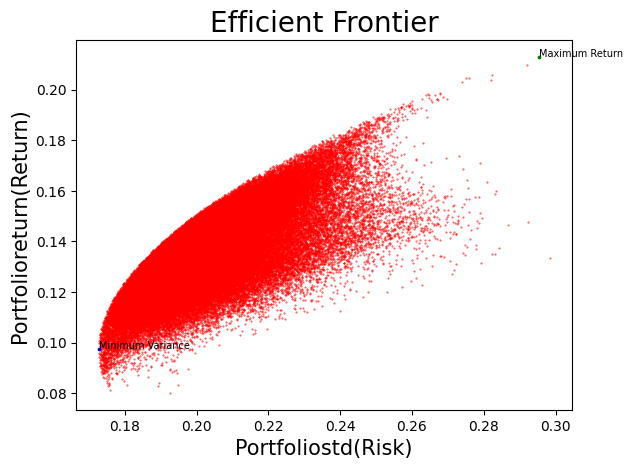

<Figure size 3000x2000 with 0 Axes>

In [8]:
plt.scatter(stds,returns,c="red",s=0.2,alpha=0.75) #Customise size according to number of iterations being plotter
plt.scatter(stds[returns.index(max(returns))], max(returns),c = "green", s=3) #Customise size for this too
plt.text(stds[returns.index(max(returns))],max(returns),"Maximum Return", fontsize=7) #Customise font size for this too
plt.scatter(min(stds),returns[stds.index(min(stds))] ,c = "blue", s=3) #Customise size for this too
plt.text(min(stds),returns[stds.index(min(stds))],"Minimum Variance", fontsize=7) #Customise font size for this too
plt.title("Efficient Frontier", fontsize = 20)
plt.xlabel("Portfoliostd(Risk)", fontsize = 15)
plt.ylabel("Portfolioreturn(Return)", fontsize = 15)
plt.figure(figsize=(30,20))
plt.show()

## Finding Max Returns and Associated Risk

In [9]:
print("Max return =", max(returns))
print("Corresponding Standard Deviation =", stds[returns.index(max(returns))])

Max return = 0.2129977258580373
Corresponding Standard Deviation = 0.2954292446264196


# Creating a Function to Return Weights of Portfolios with Returns >= Max Returns According to Efficient Frontier

In [10]:
for i in range(1000000): #Use the number of iterations you seem fit
    weights = weightscreator(stocks_lr)
    if (portfolioreturn(weights) >= max(returns)):
        weight_new = weights
        print("Your Efficient Portfolio is:",weight_new) #Returns portfolio weights for above condition being satisfied
        break
         

Your Efficient Portfolio is: [9.43986545e-01 6.81982506e-03 2.43414932e-02 6.22479658e-04
 2.42296571e-02]


## Sanity Check — Verifying Monte Carlo Against Individual Stock Returns
Comparing the maximum return found by the Monte Carlo simulation against individual stock returns to validate simulation accuracy. Note that Monte Carlo may not always find the true maximum as it relies on random weight generation.

In [11]:
# Sanity check - verify Monte Carlo against individual stock returns
print("Individual Stock Annualised Returns:")
for stock, col in zip(stocks, stocks_lr.columns):
    annual_return = stocks_lr[col].mean() * 252
    print(f"{stock}: {annual_return:.2%}")

print(f"\nBest return found by Monte Carlo: {max(returns):.2%}")
print(f"This should be close to the highest individual stock return above")

Individual Stock Annualised Returns:
AAPL: 22.20%
JNJ: 8.66%
JPM: 16.65%
KO: 7.14%
XOM: 13.60%

Best return found by Monte Carlo: 21.30%
This should be close to the highest individual stock return above


## Maximum Return Portfolio Allocation
The portfolio weights below correspond to the highest returning portfolio found by the Monte Carlo simulation. As expected, the allocation is heavily concentrated in the best performing stock (AAPL) over the 2020-2025 period, reflecting a key limitation of unconstrained mean-variance optimisation — it tends to over-allocate to recent winners without any maximum weight constraint.

In [12]:
# Display weights with stock names for clarity
print("Maximum Return Portfolio Allocation:")
for stock, weight in zip(stocks, weight_new):
    print(f"{stock}: {weight:.2%}")

Maximum Return Portfolio Allocation:
AAPL: 94.40%
JNJ: 0.68%
JPM: 2.43%
KO: 0.06%
XOM: 2.42%


In [13]:
print("Returns corresponding to weights found :",portfolioreturn(weight_new)) #Prints return of found weights
print("Risk associated with weights found :",portfoliostd(weight_new)) #Prints Risk of found weights

Returns corresponding to weights found : 0.21753376477645167
Risk associated with weights found : 0.3060741779904532


## Diversification Advantage: Better Returns at the Same Risk Level
For each stock's individual risk level, we identify the best performing diversified portfolio within ±1% risk tolerance. The results demonstrate that for the same level of risk an investor takes holding an individual stock, a diversified portfolio consistently achieves higher returns — proving the core MPT thesis that diversification generates superior returns without taking on additional risk.(We cant have a portfolio as risky as Apple for positive weightages.)


In [14]:
# For each stock's individual risk level, 
# find what return the diversified portfolio achieves at that same risk
# This proves diversification gives MORE return for the SAME risk

print("Diversification Advantage:")
print("-" * 60)
print(f"{'Stock':<8} {'Indiv. Return':>15} {'Indiv. Risk':>12} {'Portfolio Return @ Same Risk':>28}")
print("-" * 60)

for stock, col in zip(stocks, stocks_lr.columns):
    indiv_ret = stocks_lr[col].mean() * 252
    indiv_std = stocks_lr[col].std() * np.sqrt(252)
    
    # Find portfolios in Monte Carlo with similar risk level
    tolerance = 0.03  # within 3% of stock's risk
    similar_risk = [(r, s) for r, s in zip(returns, stds) 
                    if abs(s - indiv_std) < tolerance]
    
    if similar_risk:
        best_port_return = max([r for r, s in similar_risk])
        print(f"{stock:<8} {indiv_ret:>14.2%} {indiv_std:>12.2%} {best_port_return:>28.2%}")
    else:
        print(f"{stock:<8} {indiv_ret:>14.2%} {indiv_std:>12.2%} {'No match found':>28}")

Diversification Advantage:
------------------------------------------------------------
Stock      Indiv. Return  Indiv. Risk Portfolio Return @ Same Risk
------------------------------------------------------------
AAPL             22.20%       31.75%                       21.30%
JNJ               8.66%       19.63%                       17.32%
JPM              16.65%       31.34%                       21.30%
KO                7.14%       20.37%                       17.80%
XOM              13.60%       32.84%               No match found


## The Core Insight of MPT: Same Return, Lower Risk
For each stock's individual return, we find the diversified portfolio that achieves the same return within ±1.5% tolerance. The result demonstrates that diversification consistently achieves the same return as individual stocks but at considerably lower risk — this is the fundamental argument for portfolio diversification over single stock investing.(We cant find better retuens than apple but we can have similar returns with lower risks)

In [15]:
# Core MPT Proof: Same return, lower risk through diversification
print("Core MPT Insight - Same Return, Lower Risk Through Diversification:")
print("-" * 60)

for col in stocks_lr.columns:
    indiv_ret = stocks_lr[col].mean() * 252
    indiv_std = stocks_lr[col].std() * np.sqrt(252)
    
    # Find portfolios within 1% of this stock's return
    tolerance = 0.015
    similar_return = [(r, s) for r, s in zip(returns, stds)
                      if abs(r - indiv_ret) < tolerance]
    
    if similar_return:
        min_port_std = min([s for r, s in similar_return])
        risk_reduction = indiv_std - min_port_std
        print(f"{col}:")
        print(f"  Individual Stock: Return={indiv_ret:.2%}, Risk={indiv_std:.2%}")
        print(f"  Diversified Portfolio: Same Return(+-1.5%), Risk={min_port_std:.2%}")
        print(f"  Risk Saved by Diversifying: {risk_reduction:.2%}")
        print()
    else:
        print(f"{col}: No portfolio match found within 1% return tolerance")
        print()

Core MPT Insight - Same Return, Lower Risk Through Diversification:
------------------------------------------------------------
AAPL:
  Individual Stock: Return=22.20%, Risk=31.75%
  Diversified Portfolio: Same Return(+-1.5%), Risk=29.21%
  Risk Saved by Diversifying: 2.54%

JNJ:
  Individual Stock: Return=8.66%, Risk=19.63%
  Diversified Portfolio: Same Return(+-1.5%), Risk=17.27%
  Risk Saved by Diversifying: 2.36%

JPM:
  Individual Stock: Return=16.65%, Risk=31.34%
  Diversified Portfolio: Same Return(+-1.5%), Risk=20.08%
  Risk Saved by Diversifying: 11.25%

KO:
  Individual Stock: Return=7.14%, Risk=20.37%
  Diversified Portfolio: Same Return(+-1.5%), Risk=17.41%
  Risk Saved by Diversifying: 2.96%

XOM:
  Individual Stock: Return=13.60%, Risk=32.84%
  Diversified Portfolio: Same Return(+-1.5%), Risk=17.85%
  Risk Saved by Diversifying: 14.99%



## Capital Market Line (CML)
The CML is drawn from the risk-free rate (US 1-Year T-bill: 4%, 31 Dec 2025) tangent to the Efficient Frontier. The tangency point represents the Maximum Sharpe Ratio Portfolio — the optimal portfolio that maximises risk-adjusted return. Any point on the CML represents a combination of the risk-free asset and the tangency portfolio.

Maximum Sharpe Ratio: 0.60
Tangency Portfolio Return: 19.24%
Tangency Portfolio Risk: 25.39%


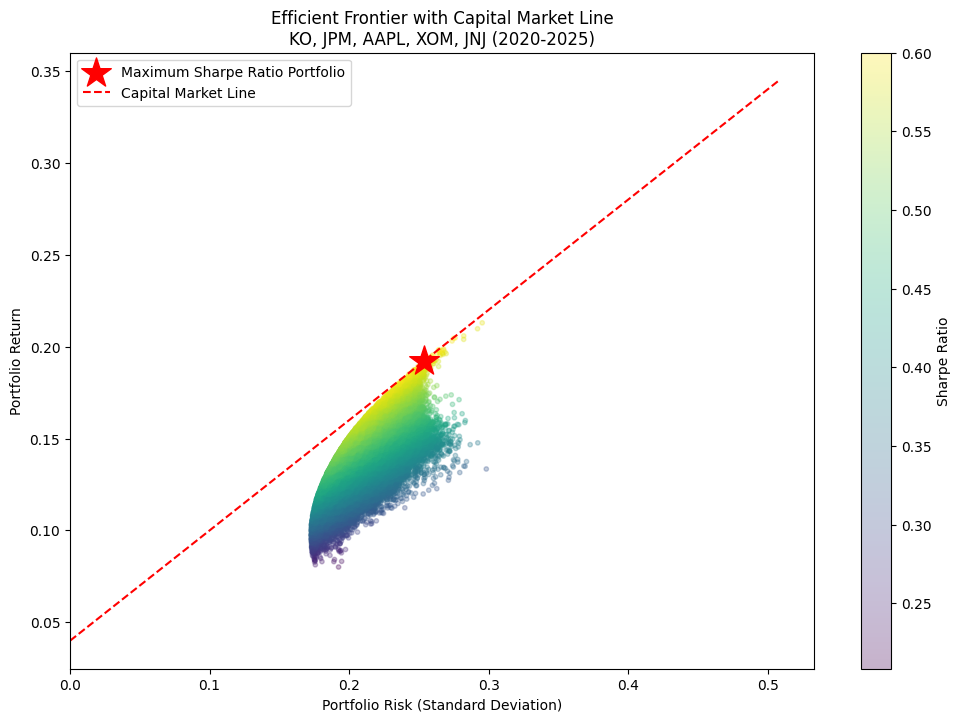

In [16]:
# Capital Market Line (CML)
# Using current US T-bill rate as risk free rate
risk_free_rate = 0.04  # 4% US Treasury bill rate as of 2025

# Calculate Sharpe Ratio for each portfolio
sharpe_ratios = (np.array(returns) - risk_free_rate) / np.array(stds)

# Find the Maximum Sharpe Ratio Portfolio (Tangency Portfolio)
max_sharpe_idx = np.argmax(sharpe_ratios)
max_sharpe_return = returns[max_sharpe_idx]
max_sharpe_std = stds[max_sharpe_idx]

print(f"Maximum Sharpe Ratio: {sharpe_ratios[max_sharpe_idx]:.2f}")
print(f"Tangency Portfolio Return: {max_sharpe_return:.2%}")
print(f"Tangency Portfolio Risk: {max_sharpe_std:.2%}")

# Plot Efficient Frontier with CML
plt.figure(figsize=(12,8))
plt.scatter(stds, returns, c=sharpe_ratios, cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

# Plot tangency portfolio
plt.scatter(max_sharpe_std, max_sharpe_return, c='red', marker='*', s=500, label='Maximum Sharpe Ratio Portfolio')

# Plot Capital Market Line
cml_x = [0, max_sharpe_std * 2]
cml_y = [risk_free_rate, risk_free_rate + (max_sharpe_return - risk_free_rate) / max_sharpe_std * max_sharpe_std * 2]
plt.plot(cml_x, cml_y, 'r--', label='Capital Market Line')

plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Return')
plt.title('Efficient Frontier with Capital Market Line\nKO, JPM, AAPL, XOM, JNJ (2020-2025)')
plt.xlim(left=0)
plt.legend()
plt.show()